## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from classy import Class

### Importing from files

In [2]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from relativistic_degrees_of_freedom import RelativisticDegreesOfFreedom

In [3]:
# Now import module: evaluate A(log(m_a)), b(log(m_a)) and mu(log(m_a)) for muon scattering
from axion_production.muon_scattering import evaluate_parameter

## Stored Dist Part: Fit to analytical formula: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

In [4]:
# --- here we will use the formulat, which comes from polynomial fit to
# the analytcial formula developed in our code
coeffs = np.array(
        [4.81885051e-07,  6.32810759e-06,  2.48531307e-05, -2.35664253e-05,
       -4.33120722e-04, -9.40960466e-04,  1.05258796e-03,  7.10662939e-03,
        6.50360435e-03, -1.65177381e-02, -3.87649755e-02,  2.77565176e-03,
        8.56384059e-02,  4.68204306e-02, -1.20385937e-01, -7.60326281e-02,
        2.48047947e-01,  2.91812983e-01]
)

# Create a polynomial function based on the fitted coefficients
polynomial_of_delta_n_eff = np.poly1d(coeffs)

In [5]:
N_eff_fit = polynomial_of_delta_n_eff(np.log(6.23))
print("N_eff_fit:", N_eff_fit)

N_eff_fit: 0.47251875298129586


## CLASS PART: Find today temperature of axion: $T_{\mathrm{ncdm}}$

More details about this calculation can be found in 2211.03799 on page: 13.

In [6]:
RelativisticDOF = RelativisticDegreesOfFreedom()

In [7]:
# --- Set axion process of production and corresponding dof ---
muon_mass = 105.66*10**6  # [eV]
muon_mass_MeV = 105.66  # [MeV]
x_dec_muon = 20  # decouple from the plasma
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(muon_mass, x_dec_muon)
print(f"muon mass: {muon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")

# Set neutrinos decouple temperature and find corresponding dof
neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")
print(f"kB*T for neutrino decouple: {neutrino_decouple_T*10**(-6)} [MeV]," 
      f"corresponds to: {neutrino_decouple_dof} relativistic dof of entropy")

muon mass: 105.66 [MeV], corresponds to: 10.741705622990075 relativistic dof of entropy
kB*T for neutrino decouple: 3.0 [MeV],corresponds to: 10.721487622640407 relativistic dof of entropy


In [8]:
g_s_star_ratio = (neutrino_decouple_dof/axion_decouple_dof)
print("g_s_star_ratio:", g_s_star_ratio)

g_s_star_ratio: 0.9981178035351856


In [9]:
def calculate_T_axion(_g_s_star_ratio):
    """
    Calculate temperature of axion in selected process of production. For our reference
    T_nu = 0.71611 [T_gamma] is temperature of neutrinos. Variables `_g_s_star_ratio`:
    is the ratio between entropy degrees of freedom (dof) of axion (in moment of decople)
    and neutrinos (in moment of decouple).
    """
    return 0.71611 * (_g_s_star_ratio)**(1/3) # in units of photon temperature [T_gamma]

## Base parameters setting (we do not vary them)

In [10]:
# --- Define the cosmological parameters for LambdaCDM + neutrinos + axions ---
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.67556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino and axion related parameters
    'N_ur': 0.0,
    'N_ncdm': '2',              # two species: neutrinos and axions
    'deg_ncdm': '3, 1',         # 3 degenerate neutrinos and axion

    # Basic settings
    # 'use_ncdm_psd_files': '0, 0',
    
    # Extra settings
    # 'perturbed_recombination': 'yes',       # consider perturbed recombination
    # 'ceff2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    # 'cvis2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    'ncdm_quadrature_strategy': '0, 0',    # is the method used for the momentum sampling of the ncdm distribution function: 0, 1, 2, 3
    # 'ncdm_maximum_q': '15, 20',
    # 'Number of momentum bins': '150, 200'  # More momentum bins for better resolution

}

In [11]:
# the range of parameters, which we gonna investigate
max_axion_mass = 5.691    # [eV]
min_axion_mass = 0.05691  # [eV]
Nums = 100
axion_masses = np.logspace(np.log10(min_axion_mass), np.log10(max_axion_mass), num=Nums)  # [eV]
nuetrino_mass = 0.06  # [eV]
T_neutrinos = 0.71611  # in units of photon temperature [T_gamma]
# print(axion_masses)

# prepare list
Neff_base = 3.039594664360296  # 3.039594664360296, 3.044
deltaNeff_list = []

### Varied parameters (axion masses and distribution)

In [12]:
cosmo_dict = {}
#
for i in range(0, Nums):
    # --- Find physcial values
    m_a = axion_masses[i]  # [eV]
    log_m_a = np.log(m_a)  # [log(eV)]
    T_axion = calculate_T_axion(g_s_star_ratio) # in units of photon temperature [T_gamma]

    # --- Find parameters for selected axion masses
    A = evaluate_parameter("A", log_m_a)
    b = evaluate_parameter("b", log_m_a)
    mu = evaluate_parameter("mu", log_m_a)
    
    # --- Call CLASS
    if i % 10 == 0:
        print("I'm calculate for:", m_a, "[eV]", T_axion, "[T_gamma], index:", i)

    cosmo_dict[i] = Class()
    cosmo_dict[i].set(params)
    cosmo_dict[i].set({'m_ncdm': f'{nuetrino_mass}, {m_a}'})     # Masses of neutino and axion
    cosmo_dict[i].set({'T_ncdm': f'{T_neutrinos}, {T_axion}'})   # Temperature of neutino and axion
    cosmo_dict[i].set({'ncdm_psd_parameters': f'{A},{b},{mu}'})  # Axion distribution function
    cosmo_dict[i].compute()

I'm calculate for: 0.05690999999999999 [eV] 0.7156604312528716 [T_gamma], index: 0
I'm calculate for: 0.09061681376904154 [eV] 0.7156604312528716 [T_gamma], index: 10
I'm calculate for: 0.14428759335183905 [eV] 0.7156604312528716 [T_gamma], index: 20
I'm calculate for: 0.2297466521867299 [eV] 0.7156604312528716 [T_gamma], index: 30
I'm calculate for: 0.3658216411046507 [eV] 0.7156604312528716 [T_gamma], index: 40
I'm calculate for: 0.5824915045627358 [eV] 0.7156604312528716 [T_gamma], index: 50
I'm calculate for: 0.9274911999826085 [eV] 0.7156604312528716 [T_gamma], index: 60
I'm calculate for: 1.4768282787075901 [eV] 0.7156604312528716 [T_gamma], index: 70
I'm calculate for: 2.3515282569056386 [eV] 0.7156604312528716 [T_gamma], index: 80
I'm calculate for: 3.7442979815262203 [eV] 0.7156604312528716 [T_gamma], index: 90


In [13]:
# --- Finding all deltaNeff values
for i in range(0, Nums):
    derived_params = cosmo_dict[i].get_current_derived_parameters(['Neff'])  # derived parameters
    deltaNeff = derived_params['Neff'] - Neff_base
    deltaNeff_list.append(deltaNeff)

print("lowest value of \Delta N_eff:", min(deltaNeff_list))

lowest value of \Delta N_eff: 0.0019955026003408705


## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

In [14]:
def calculate_fa(ma):
    """
    Calculate the f_a value from a given axion mass m_a in eV based on the axion mass
    formula from particle physics. The relationship between the axion decay constant f_a
    and the axion mass m_a is given by the specific scale factor derived from theoretical
    models which predict f_a inversely proportional to m_a.

    This specific formula is referenced from a particle physics review publication:
    https://pdg.lbl.gov/2023/reviews/rpp2023-rev-axions.pdf

    Parameters:
    ma (float): The mass of the axion in eV.

    Returns:
    float: The axion decay constant f_a in GeV.
    """
    fa = (5.691 * 10 ** 6) / ma  # [GeV]
    return fa  # [GeV]

In [15]:
# Find decay constants: f_a
decay_constants = calculate_fa(axion_masses)

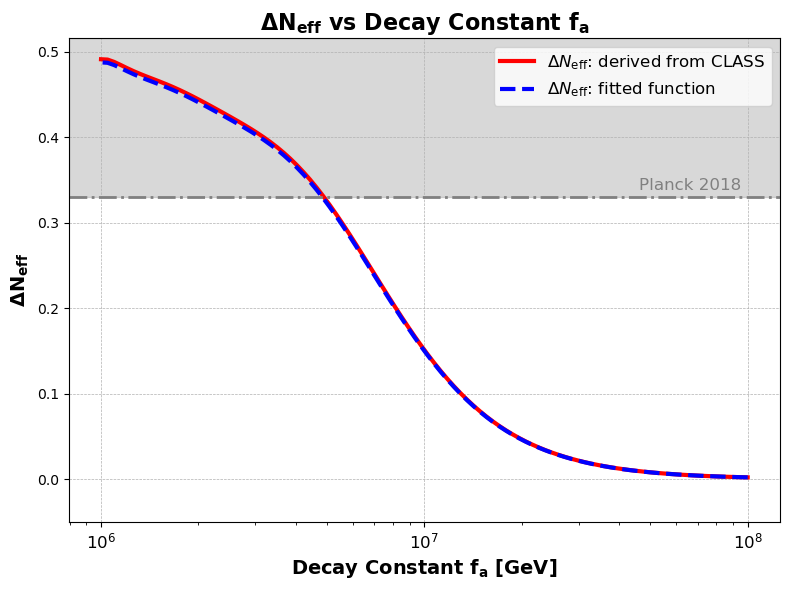

In [16]:
# Create the figure with improved aesthetics
fig, axs = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs.plot(decay_constants, deltaNeff_list, 
            color='r', lw=3, label=r'$\Delta N_{\rm{eff}}$: derived from CLASS')
axs.plot(decay_constants, polynomial_of_delta_n_eff(np.log(axion_masses)), 
            color='b', label=r'$\Delta N_{\rm{eff}}$: fitted function', lw=3, ls="--")
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs.text(decay_constants[1], planck_limit + 0.005, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('Fits_of_delta_N_eff_and_axion_mass.png', format='png', dpi=300)
# plt.close()

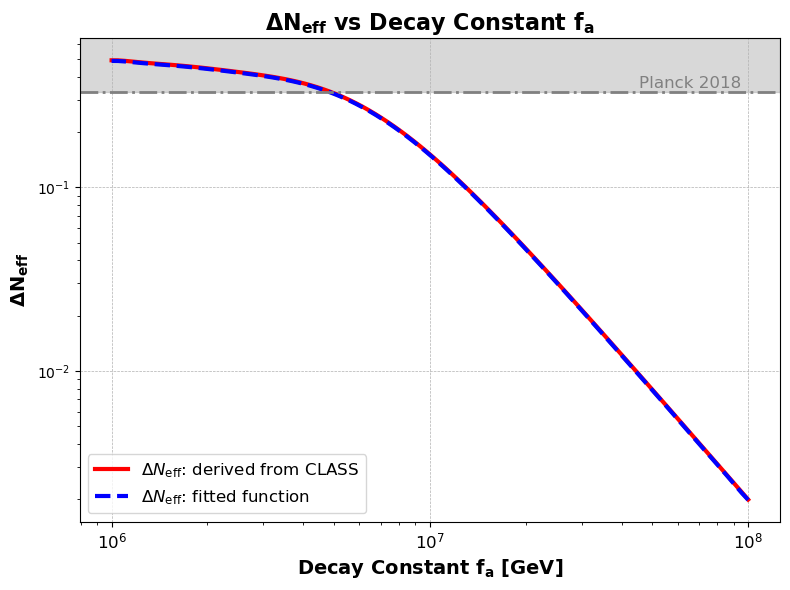

In [17]:
# ------------- LogLog Plot: \Delta N_eff vs m_a
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
ax.plot(decay_constants, deltaNeff_list, 
            color='r', lw=3, label=r'$\Delta N_{\rm{eff}}$: derived from CLASS')
ax.plot(decay_constants, polynomial_of_delta_n_eff(np.log(axion_masses)), 
            color='b', label=r'$\Delta N_{\rm{eff}}$: fitted function', lw=3, ls="--")

# --- Other settings
# Set xy-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title with bold text
ax.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
ax.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
ax.text(decay_constants[1], planck_limit + 0.005, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [18]:
# --- Check the differences between ΔN_eff_fit and ΔN_eff_points ---
print(f"{'Axion Mass [eV]':<20}{'ΔN_eff (CLASS)':>20}{'ΔN_eff (Fit)':>20}{'Rel. Diff. [%]':>20}")
print("=" * 80)

rel_diff_arr = []

for i in range(Nums):
    m_a = axion_masses[i]  # Axion mass in eV
    N_eff_class = deltaNeff_list[i]  # Best values from distribution
    N_eff_fit = polynomial_of_delta_n_eff(np.log(m_a))  # Fitted function values

    # Compute relative difference in percentage
    rel_diff = 100 * abs(N_eff_class - N_eff_fit) / abs(N_eff_class) if N_eff_class != 0 else 0
    rel_diff_arr.append(rel_diff)

    print(f"{m_a:<20.6e}{N_eff_class:>20.6e}{N_eff_fit:>20.6e}{rel_diff:>20.6f}")

Axion Mass [eV]           ΔN_eff (CLASS)        ΔN_eff (Fit)      Rel. Diff. [%]
5.691000e-02                1.995503e-03        1.988580e-03            0.346886
5.961981e-02                2.190282e-03        2.168013e-03            1.016690
6.245865e-02                2.403102e-03        2.381640e-03            0.893069
6.543267e-02                2.636168e-03        2.617881e-03            0.693691
6.854830e-02                2.891730e-03        2.873784e-03            0.620599
7.181228e-02                3.172116e-03        3.151096e-03            0.662623
7.523167e-02                3.479765e-03        3.453629e-03            0.751087
7.881388e-02                3.817273e-03        3.785687e-03            0.827456
8.256667e-02                4.187425e-03        4.151294e-03            0.862862
8.649814e-02                4.593238e-03        4.553964e-03            0.855037
9.061681e-02                5.037999e-03        4.996809e-03            0.817580
9.493160e-02                

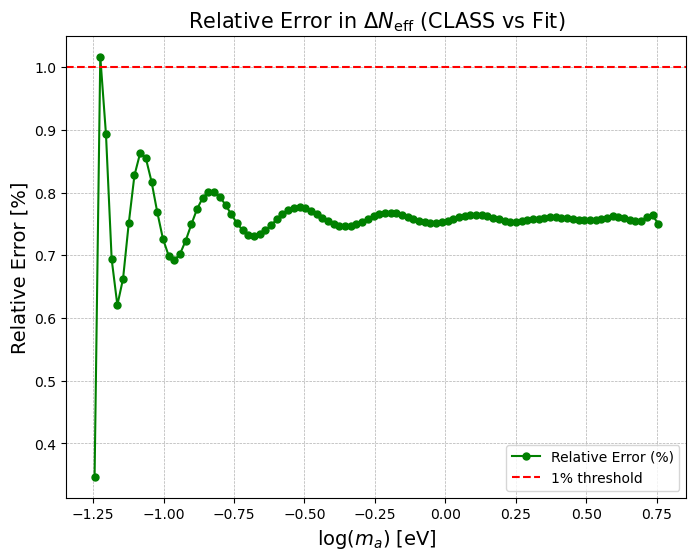

In [19]:
# Convert axion masses to log scale
log_masses = np.log10(axion_masses)

plt.figure(figsize=(8, 6))

# Plot relative error as a function of axion mass
plt.plot(log_masses, rel_diff_arr, 'go-', label=r'Relative Error (%)', markersize=5)

# Add a horizontal line at 1% to highlight the accuracy threshold
plt.axhline(y=1, color='r', linestyle='--', label='1% threshold')

plt.xlabel(r'$\log(m_a)$ [eV]', fontsize=14)
plt.ylabel(r'Relative Error [%]', fontsize=14)
plt.title(r'Relative Error in $\Delta N_{\mathrm{eff}}$ (CLASS vs Fit)', fontsize=15)

# Use logarithmic y-scale if errors span multiple orders of magnitude
# plt.yscale("log")  

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()